In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
from google.colab import drive
# drive.mount('/content/drive')

# df = pd.read_csv('/content/drive/MyDrive/Google Colab/SVM&KNN/Titanic-Dataset.csv')
train_url = "https://raw.githubusercontent.com/SIAM0808/Artificial_Intelligence_and_Machine_Learning_Lab/main/SVM%20%26%20KNN/KNN/Dataset/Titanic-Dataset.csv"
df = pd.read_csv(train_url)

print("Dataset loaded! Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Mounted at /content/drive
Dataset loaded! Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Preprocessing

In [ ]:
print(" Missing values before cleaning:")
print(df.isnull().sum())

# 4b. Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

print("\n Missing values after cleaning:")
print(df.isnull().sum())

# 4c. Encode categorical features
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])           # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked']) # C=0, Q=1, S=2

print("\n Categorical encoding done!")
print(df.head())

 Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

 Categorical encoding done!
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


# Split & Normalize Data

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Second split: 75% train, 25% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

# Normalize/Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f" Data split complete!")
print(f"  Training set:   {X_train.shape[0]} samples")
print(f"  Validation set: {X_val.shape[0]} samples")
print(f"  Test set:       {X_test.shape[0]} samples")

 Data split complete!
  Training set:   534 samples
  Validation set: 178 samples
  Test set:       179 samples


# Train SVM Model

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

val_acc = svm_model.score(X_val, y_val)
print(f" SVM Model trained!")
print(f"  Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

 SVM Model trained!
  Validation Accuracy: 0.8596 (85.96%)


# Hyperparameter Tuning

In [ ]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 'auto'],
    'degree': [2, 3]   # only used by poly kernel
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f"   Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

# Use best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Best Parameters: {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
   Best CV Accuracy: 80.89%


# Evaluation Metrics

In [ ]:
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc   = auc(fpr, tpr)

print("=" * 45)
print("         EVALUATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC       : {roc_auc:.4f}")
print("=" * 45)
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

         EVALUATION METRICS
  Accuracy  : 0.8156  (81.56%)
  Precision : 0.8214
  Recall    : 0.6667
  F1-Score  : 0.7360
  AUC       : 0.8333

Detailed Report:

              precision    recall  f1-score   support

Not Survived       0.81      0.91      0.86       110
    Survived       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



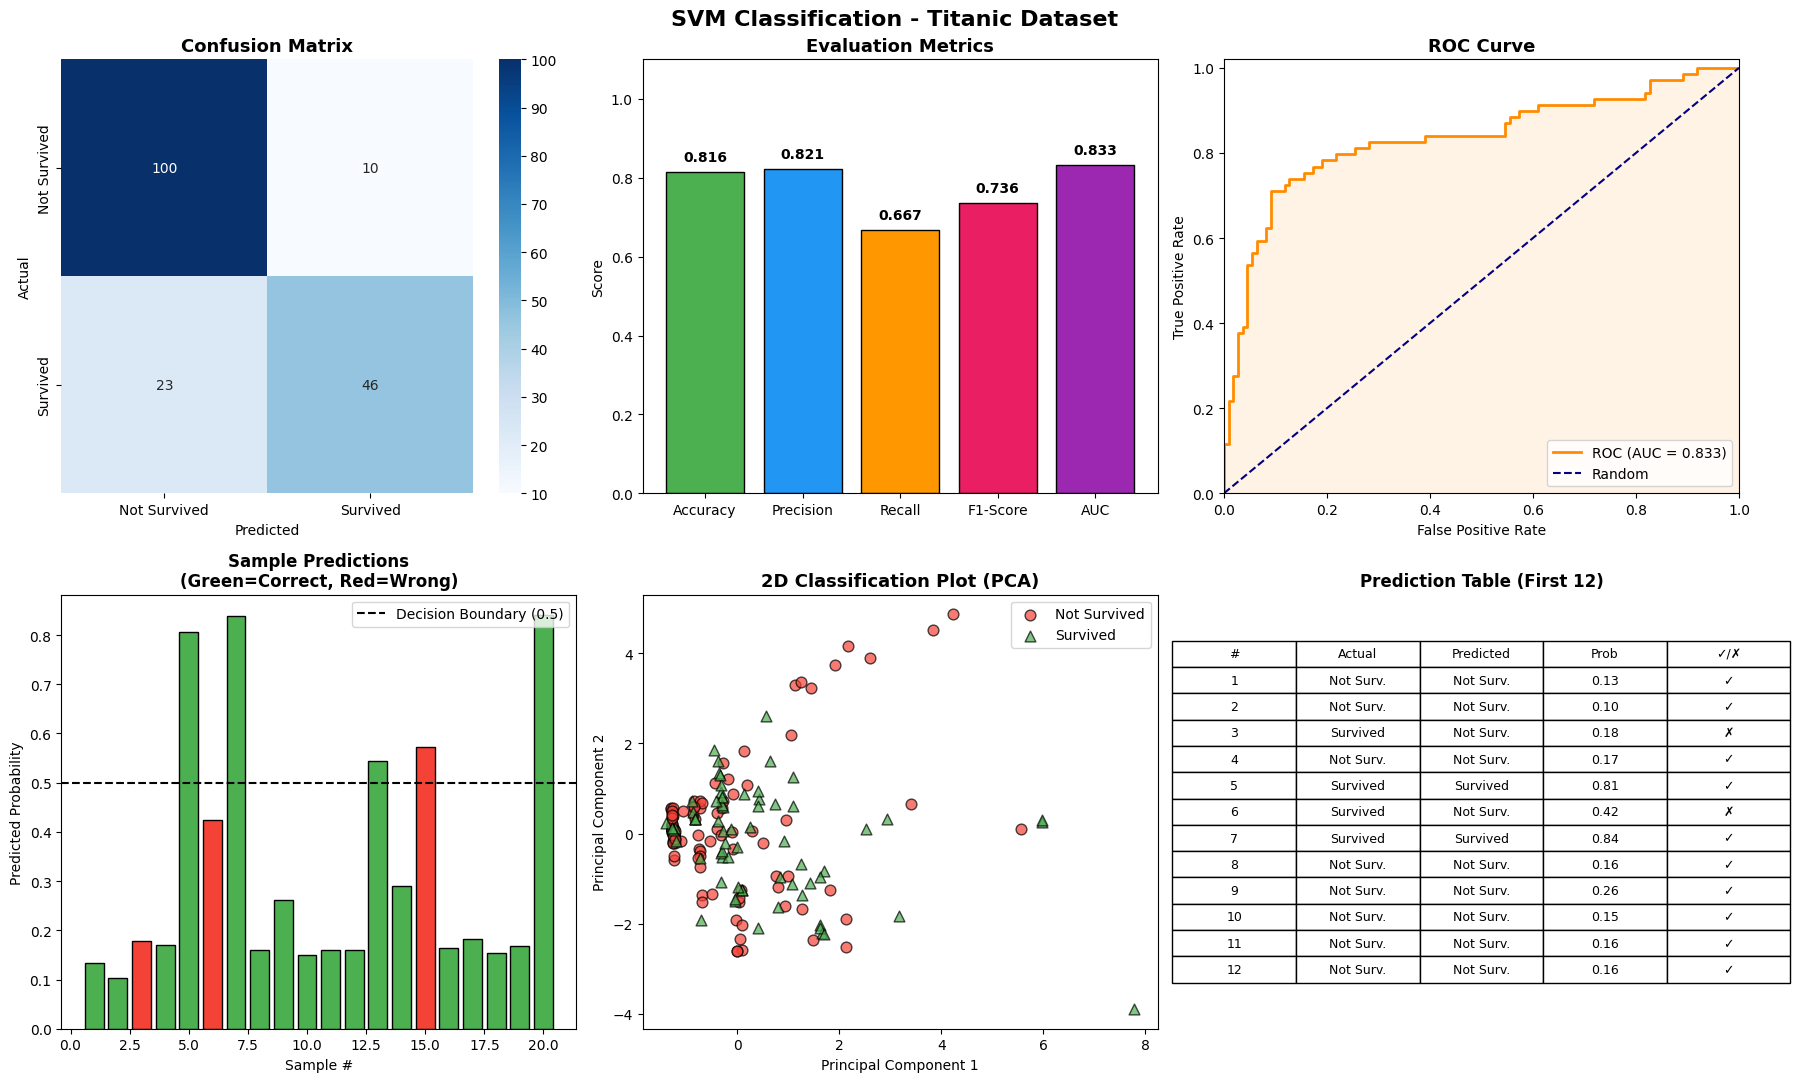

✅ All plots generated and saved as 'svm_results.png'


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('SVM Classification - Titanic Dataset', fontsize=16, fontweight='bold')

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
axes[0,0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# --- Plot 2: Evaluation Metrics Bar Chart ---
metrics = ['Accuracy','Precision','Recall','F1-Score','AUC']
values  = [accuracy, precision, recall, f1, roc_auc]
colors  = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0']
bars = axes[0,1].bar(metrics, values, color=colors, edgecolor='black')
axes[0,1].set_ylim(0, 1.1)
axes[0,1].set_title('Evaluation Metrics', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Score')
for bar, val in zip(bars, values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# --- Plot 3: ROC Curve ---
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0,2].plot([0,1],[0,1], color='navy', lw=1.5, linestyle='--', label='Random')
axes[0,2].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0,2].set_xlim([0,1]); axes[0,2].set_ylim([0,1.02])
axes[0,2].set_xlabel('False Positive Rate'); axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0,2].legend(loc='lower right')

# --- Plot 4: Sample Predictions (Actual vs Predicted + Probability) ---
sample_df = pd.DataFrame({
    'Sample #'   : range(1, 21),
    'Actual'     : y_test.values[:20],
    'Predicted'  : y_pred[:20],
    'Probability': y_pred_prob[:20].round(3)
})
correct = sample_df['Actual'] == sample_df['Predicted']
axes[1,0].bar(sample_df['Sample #'], sample_df['Probability'],
              color=['#4CAF50' if c else '#F44336' for c in correct], edgecolor='black')
axes[1,0].axhline(0.5, color='black', linestyle='--', label='Decision Boundary (0.5)')
axes[1,0].set_title('Sample Predictions\n(Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Sample #'); axes[1,0].set_ylabel('Predicted Probability')
axes[1,0].legend()

# --- Plot 5: 2D Classification Plot (PCA) ---
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)
for label, marker, color, name in [(0,'o','#F44336','Not Survived'),(1,'^','#4CAF50','Survived')]:
    mask = y_test.values == label
    axes[1,1].scatter(X_test_2d[mask,0], X_test_2d[mask,1],
                      c=color, marker=marker, alpha=0.7, label=name, edgecolors='black', s=60)
axes[1,1].set_title('2D Classification Plot (PCA)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Principal Component 1')
axes[1,1].set_ylabel('Principal Component 2')
axes[1,1].legend()

# --- Plot 6: Sample Predictions Table ---
axes[1,2].axis('off')
table_data = [['#','Actual','Predicted','Prob','✓/✗']]
for _, row in sample_df.head(12).iterrows():
    status = '✓' if row['Actual']==row['Predicted'] else '✗'
    act = 'Survived' if row['Actual']==1 else 'Not Surv.'
    pred = 'Survived' if row['Predicted']==1 else 'Not Surv.'
    table_data.append([int(row['Sample #']), act, pred, f"{row['Probability']:.2f}", status])
table = axes[1,2].table(cellText=table_data[1:], colLabels=table_data[0],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.2, 1.4)
axes[1,2].set_title('Prediction Table (First 12)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('svm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All plots generated and saved as 'svm_results.png'")